In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.dates as mdates

# Overview Data

In [2]:
path = "../data/raw/vietnam_weather_2023_complete.csv"
df = pd.read_csv(path)
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13152 entries, 0 to 13151
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city                         13152 non-null  object        
 1   latitude                     13152 non-null  float64       
 2   longitude                    13152 non-null  float64       
 3   date                         13152 non-null  datetime64[ns]
 4   temperature_2m_max           13152 non-null  float64       
 5   temperature_2m_min           13152 non-null  float64       
 6   temperature_2m_mean          13152 non-null  float64       
 7   rain_sum                     13152 non-null  float64       
 8   precipitation_hours          13152 non-null  float64       
 9   weather_code                 13152 non-null  int64         
 10  sunrise                      13152 non-null  object        
 11  sunset                       13152 non-nu

- temperature_2m_max :
Nhiệt độ tối đa trong ngày (°C)
Đo ở độ cao 2m so với mặt đất
Thường xảy ra vào buổi chiều (14h-16h)

- temperature_2m_min
Nhiệt độ tối thiểu trong ngày (°C)
Thường xảy ra vào sáng sớm (5h-7h)

- temperature_2m_mean:
Nhiệt độ trung bình trong ngày (°C)
Trung bình của 24 giá trị hàng giờ


- precipitation_hour:
Tổng lượng mưa (tính theo giờ) trong một ngày 

- rain_sum
Chỉ tính lượng mưa (mm)
Không bao gồm tuyết

- weather_code: 


- wind_speed_10m_max
Tốc độ gió tối đa trong ngày (km/h hoặc m/s)
Đo ở độ cao 10m
Gió liên tục (sustained wind)

- wind_gusts_10m_max
Tốc độ giật gió tối đa (km/h hoặc m/s)
Đợt gió mạnh đột ngột, ngắn (< 20 giây)
Thường cao hơn wind_speed_max 30-50%
Quan trọng cho cảnh báo bão, giông

- wind_direction_10m_dominant (độ, 0-360°)
Hướng gió chủ đạo trong ngày
Quy ước:
0° / 360° = Gió Bắc
90° = Gió Đông
180° = Gió Nam
270° = Gió Tây
Ví dụ: 135° = Gió Đông Nam

- weather_code (WMO code)
Mã phân loại thời tiết theo chuẩn WMO (Tổ chức Khí tượng Thế giới)
Các giá trị phổ biến:
0 = Trời quang đãng
1, 2, 3 = Có mây (ít, vừa, nhiều)
45, 48 = Sương mù
51, 53, 55 = Mưa phùn (nhẹ, vừa, dày đặc)
61, 63, 65 = Mưa (nhẹ, vừa, to)
71, 73, 75 = Tuyết rơi (nhẹ, vừa, dày)
80, 81, 82 = Mưa rào (nhẹ, vừa, mạnh)
95 = Giông bão
96, 99 = Giông có mưa đá

- Relative Humidity min/max/mean: Độ ẩm không khí trong ngày 

- Dewpoint min/max/mean: 
Điểm sương 
Quy tắc vàng:
Khi dewpoint ≈ temperature (chênh < 2°C) → Sương mù, mưa
Dewpoint cao (> 24°C) → Cảm giác ẩm ướt, ngột ngạt
Ví dụ:
Nhiệt độ 28°C, dewpoint 26°C → Rất ẩm, gần mưa
Nhiệt độ 32°C, dewpoint 15°C → Khô ráo, thoáng
Dùng cho:
Dự báo sương mù (giao thông, hàng không)
Cảnh báo thời tiết nguy hiểm
Comfort index

- surface_pressure_mean 
Áp suất khí quyển tại mặt đất
Đơn vị: hectopascal (hPa) = millibar (mbar)
Giá trị chuẩn: 1013 hPa (ở mực nước biển)
Ý nghĩa:
(>) 1020 hPa = Áp cao (thời tiết đẹp, nắng)
1013 hPa = Bình thường
< 1000 hPa = Áp thấp (mưa, gió)
< 980 hPa = Áp thấp nhiệt đới (nguy hiểm)
< 950 hPa = Bão mạnh (siêu bão)

- cloudcover_mean (%)
Tỷ lệ % bầu trời bị che phủ bởi mây
Phân loại:
0-10% = Quang đãng
10-30% = Ít mây
30-70% = Có mây
70-90% = Nhiều mây
90-100% = U ám, mây dày

- shortwave_radiation_sum
Tổng năng lượng mặt trời chiếu xuống trong ngày (MJ/m²)
Bức xạ sóng ngắn (ánh sáng nhìn thấy + UV)
Dùng cho: dự báo năng lượng mặt trời, nông nghiệp

- et0_fao_evapotranspiration
Lượng nước bốc hơi tiềm năng (mm)
Theo phương pháp FAO Penman-Monteith (tiêu chuẩn quốc tế)
Tổng: bốc hơi từ đất + thoát hơi nước qua lá cây
Dùng trong nông nghiệp: Tính lượng nước cần tưới
Ví dụ: ET0 = 5mm/ngày → cần tưới 5mm nước/ngày

In [3]:
df.head()

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,wind_direction_10m_dominant,shortwave_radiation_sum,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,dewpoint_2m_max,dewpoint_2m_min,dewpoint_2m_mean,surface_pressure_mean,cloudcover_mean
0,Hanoi,21.0278,105.8342,2022-01-01,20.7,13.9,16.9,0.0,0.0,3,...,17,6.94,90,58,73.833333,12.8,11.0,12.100000,1022.095833,98.083333
1,Hanoi,21.0278,105.8342,2022-01-02,21.6,14.9,17.2,0.0,0.0,3,...,10,12.63,85,56,70.166667,13.4,10.2,11.554167,1020.462500,55.208333
2,Hanoi,21.0278,105.8342,2022-01-03,21.8,12.9,17.6,0.0,0.0,3,...,130,8.85,100,60,80.375000,14.8,12.9,14.000000,1017.841667,59.125000
3,Hanoi,21.0278,105.8342,2022-01-04,23.9,13.4,18.2,0.0,0.0,3,...,142,9.17,100,57,84.625000,17.2,13.4,15.220833,1015.637500,61.041667
4,Hanoi,21.0278,105.8342,2022-01-05,24.0,17.0,19.8,0.0,0.0,3,...,159,6.89,100,61,84.625000,18.5,16.0,16.933333,1014.058333,74.250000


In [4]:
df['weather_code'].value_counts()

weather_code
51    2960
63    2918
3     2810
53    1396
61    1244
65    1051
55     461
2      111
1      108
0       93
Name: count, dtype: int64

### Bởi vì tập trung dự đoán nắng (0), sương mù (1), mưa (2), bão (3) nên gộp weather code

In [5]:
def group_weather_codes(code):
    if code in [0, 1, 2, 3]:
        return 0
    elif code in [45, 48]:
        return 1
    elif code in [51, 53, 55, 61, 63, 65, 80, 81, 82]:
        return 2
    elif code in [95, 96, 99]:
        return 3
    else:
        return 'Other' # Cho các trường hợp khác nếu có

# Tạo một cột mới chứa các nhóm đã được gom lại
df['weather_code'] = df['weather_code'].apply(group_weather_codes)

In [6]:
df['weather_code'].value_counts()

weather_code
2    10030
0     3122
Name: count, dtype: int64

In [7]:
df.isnull().sum()

city                           0
latitude                       0
longitude                      0
date                           0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
rain_sum                       0
precipitation_hours            0
weather_code                   0
sunrise                        0
sunset                         0
sunshine_duration              0
daylight_duration              0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
relative_humidity_2m_mean      0
dewpoint_2m_max                0
dewpoint_2m_min                0
dewpoint_2m_mean               0
surface_pressure_mean          0
cloudcover_mean                0
dtype: int64

In [8]:
df.describe()

,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,sunshine_duration,...,wind_direction_10m_dominant,shortwave_radiation_sum,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,dewpoint_2m_max,dewpoint_2m_min,dewpoint_2m_mean,surface_pressure_mean,cloudcover_mean
count,13152.000000,13152.000000,13152,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,...,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000,13152.000000
mean,15.673075,107.046075,2023-07-02 12:00:00,29.744579,22.857641,25.798829,6.423540,6.900091,1.525243,30239.267156,...,159.234109,17.204288,93.993233,63.533531,81.128998,23.377418,20.639340,22.036298,1008.407248,75.864251
min,10.533600,105.547400,2022-01-01 00:00:00,9.400000,6.200000,8.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.280000,48.000000,22.000000,33.541667,1.300000,-7.600000,-1.150000,983.370833,0.000000
25%,10.904100,106.266800,2022-10-01 18:00:00,27.700000,21.700000,24.500000,0.100000,1.000000,2.000000,24138.712500,...,89.000000,13.540000,92.000000,55.000000,76.333333,22.100000,19.100000,20.733333,1005.116667,60.041667
50%,15.796900,107.038450,2023-07-02 12:00:00,30.600000,23.900000,26.600000,1.700000,5.000000,2.000000,35922.425000,...,134.000000,18.450000,96.000000,65.000000,83.166667,24.700000,22.300000,23.629167,1008.095833,84.750000
75%,21.011750,107.697950,2024-04-01 06:00:00,32.400000,25.100000,28.000000,8.300000,11.000000,2.000000,39600.000000,...,240.000000,21.770000,98.000000,73.000000,87.416667,25.700000,23.600000,24.596875,1011.379167,97.916667
max,21.567100,109.052600,2024-12-31 00:00:00,42.600000,29.600000,34.400000,269.500000,24.000000,2.000000,43810.510000,...,360.000000,26.990000,100.000000,97.000000,99.250000,29.900000,27.500000,28.058333,1029.275000,100.000000
std,4.432195,1.019781,NaN,4.338965,3.590886,3.648710,11.898623,6.727456,0.850984,13058.848267,...,97.971112,5.748099,6.117238,12.671745,8.617713,3.787314,4.500449,4.105643,5.273824,25.403413


# MAIN EDA

1. split on cities

In [9]:
cities = ["Hanoi", "Thai Nguyen", "Vinh Phuc", "Quang Ninh",
          "Da Nang", "Hue", "Quang Nam", "Khanh Hoa",
          "Ho Chi Minh", "Dong Nai", "Ba Ria Vung Tau", "Long An"]

north_cities = ["Hanoi", "Thai Nguyen", "Vinh Phuc", "Quang Ninh"]
central_cities = ["Da Nang", "Hue", "Quang Nam", "Khanh Hoa"]
south_cities = ["Ho Chi Minh", "Dong Nai", "Ba Ria Vung Tau", "Long An"]

data_thanhpho = {}
data_vungmien = {}

data_vungmien['North'] = df[df['city'].isin(north_cities)]
data_vungmien['Central'] = df[df['city'].isin(central_cities)]
data_vungmien['South'] = df[df['city'].isin(south_cities)]

for city in cities:
    data_thanhpho[city] = df[df['city'] == city]


In [10]:
def plot_region_data(region_name, region_array, param_plot, fig=(12, 24)):
    plt.figure(figsize=fig)
    for index, param in enumerate(param_plot):
        plt.subplot(len(param_plot), 1, index + 1)
        for region in region_array:
            data_city = data_vungmien[region_name][data_vungmien[region_name]['city'] == region]
            plt.plot(data_city['date'], data_city[param], label=region)
        plt.title(f"{param}")
        plt.legend()
        plt.xlabel(param)
        plt.ylabel(f"{param} value")
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        plt.xticks(rotation=45)
        plt.tight_layout()

### Temperature

1. North City

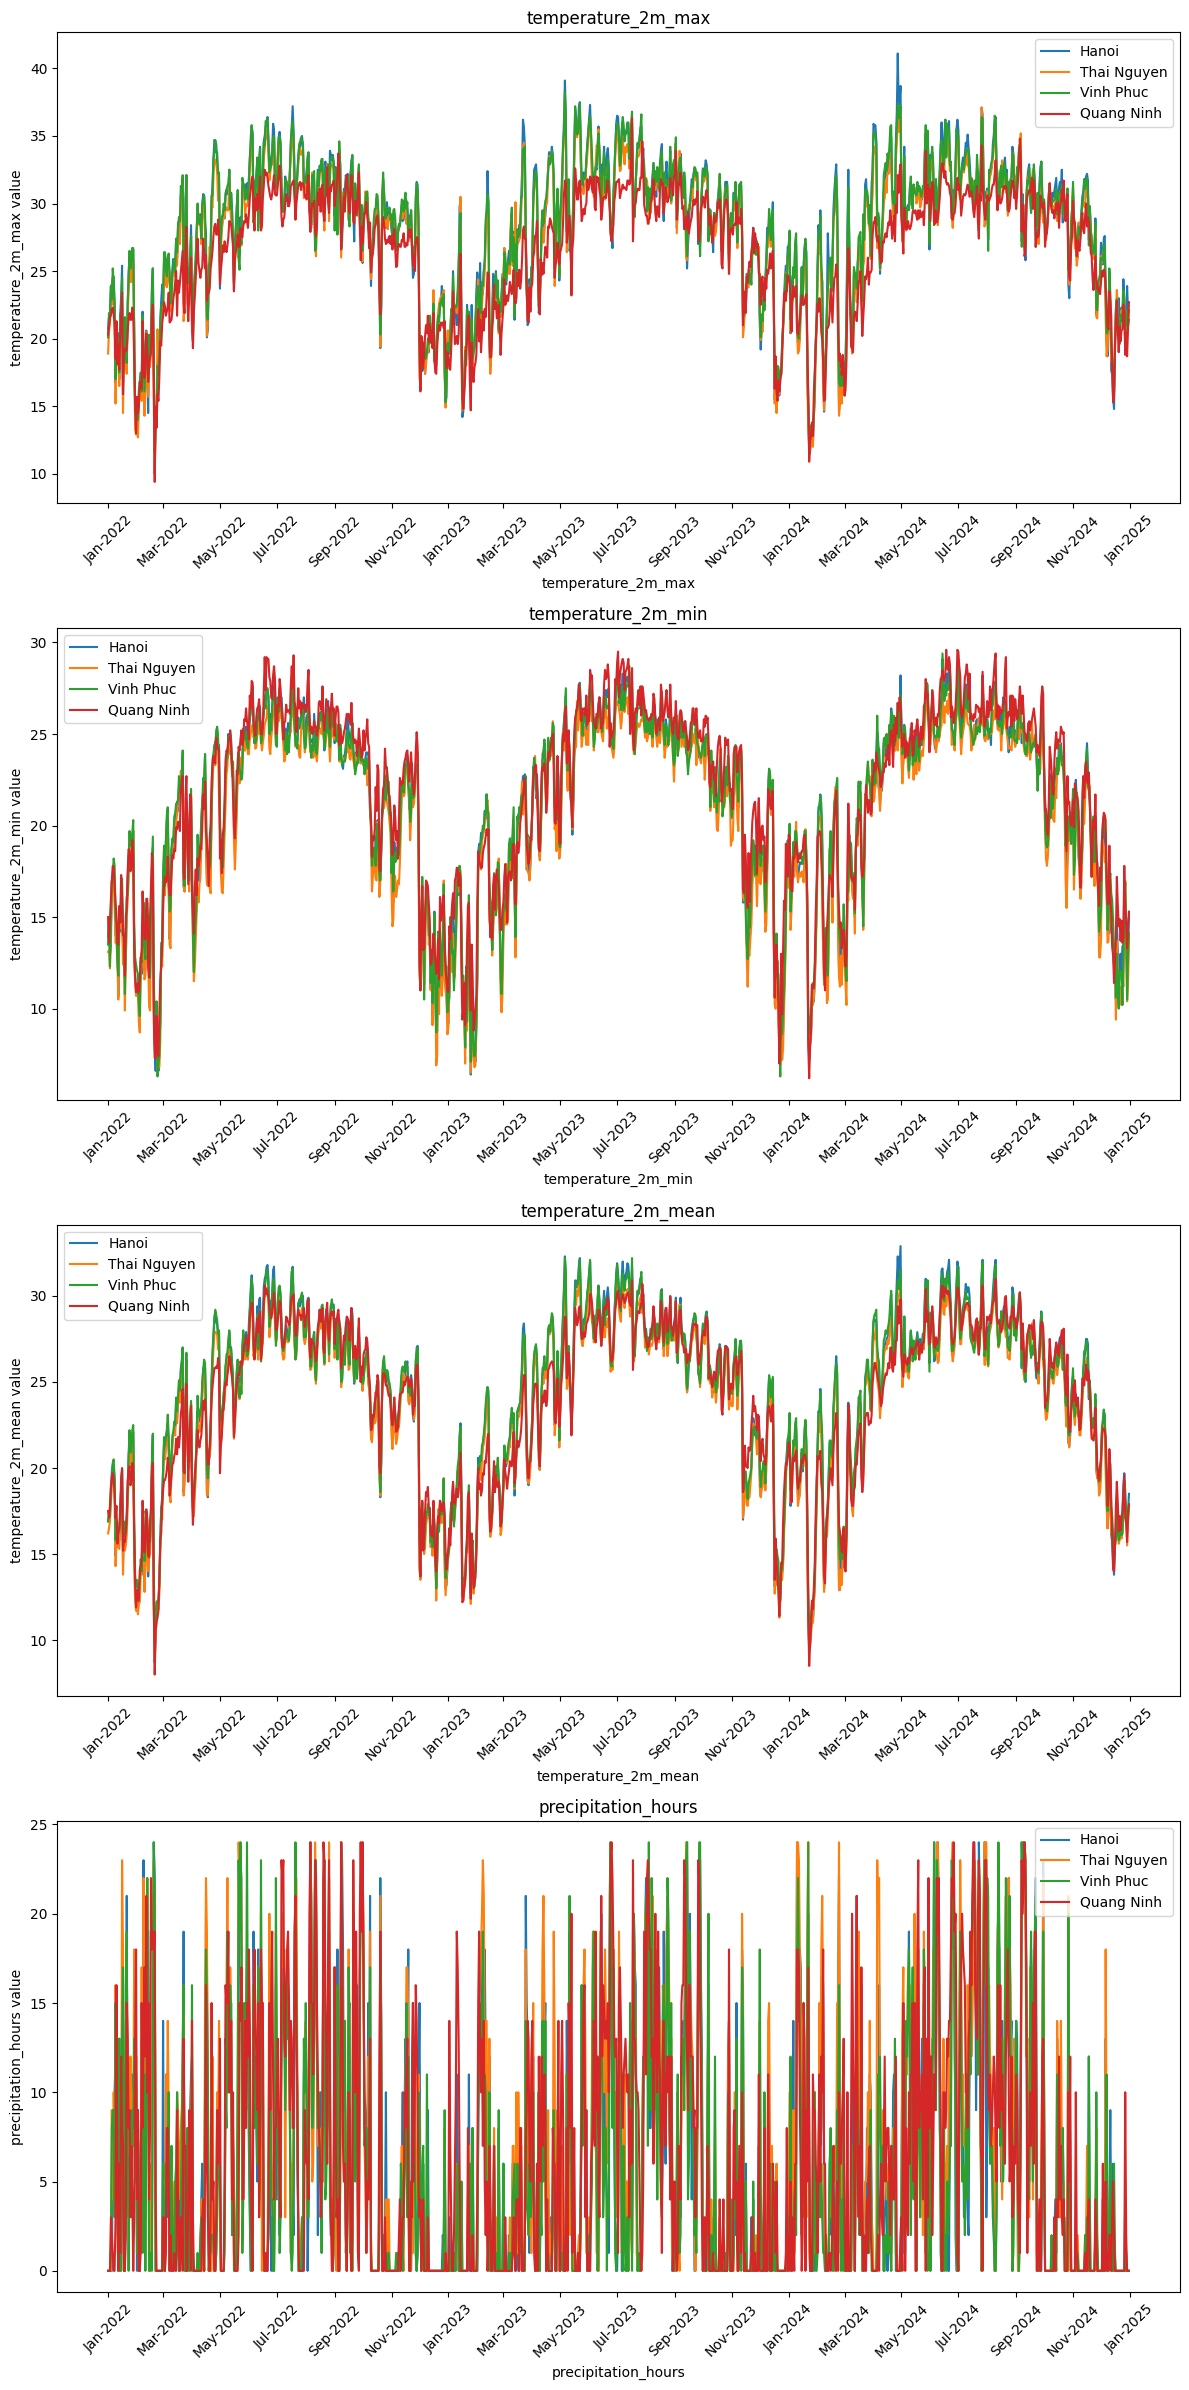

In [18]:
plot_region_data("North", north_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean", "precipitation_hours"])

2. Central City 

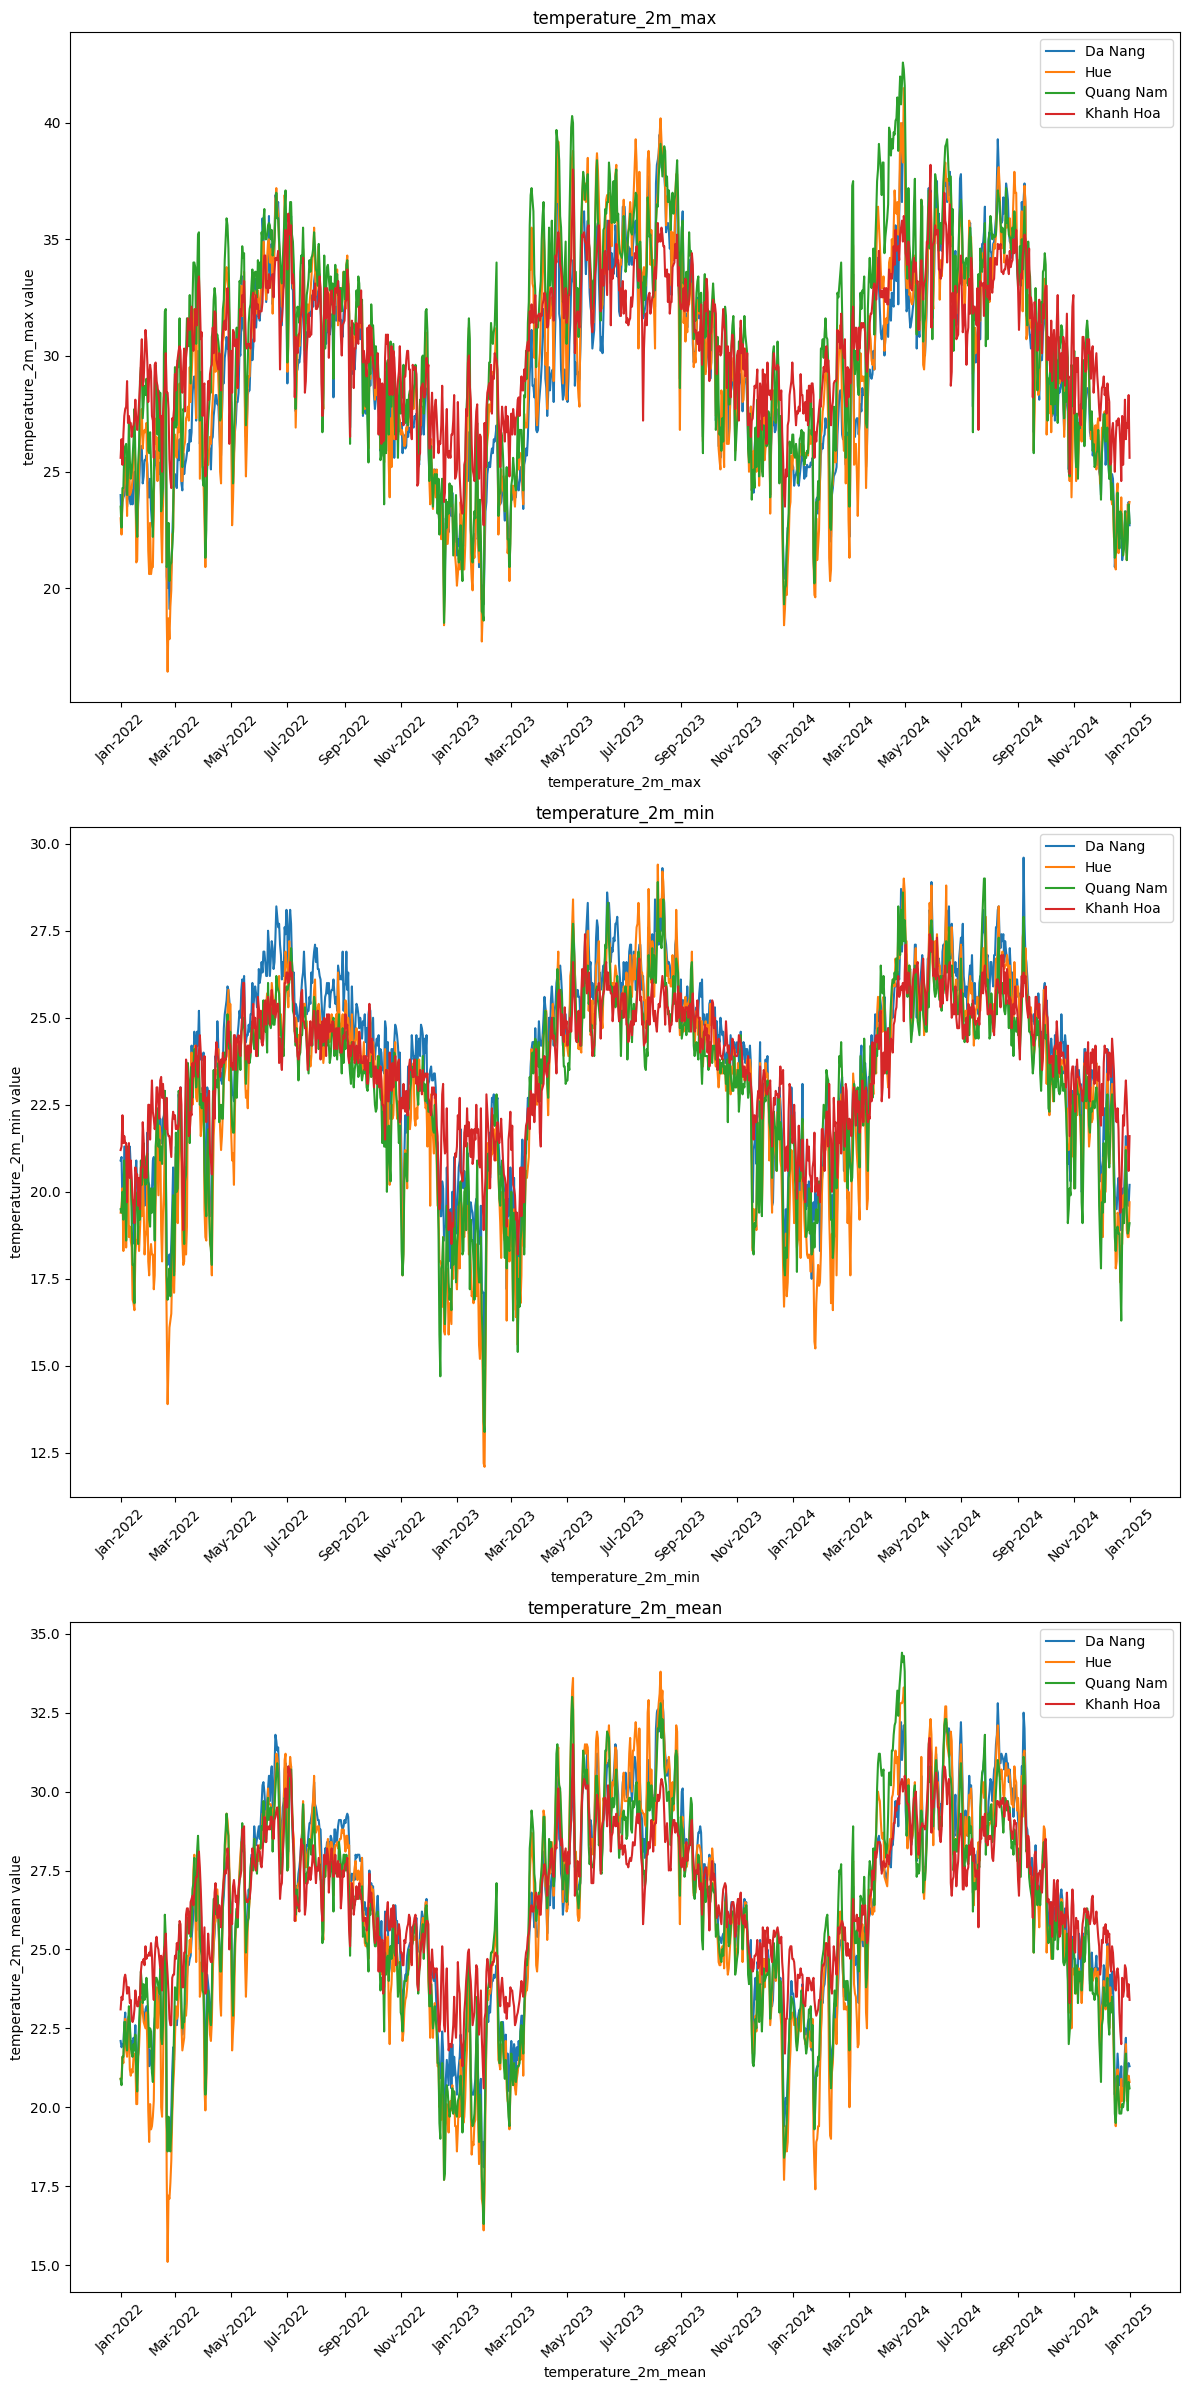

In [12]:
plot_region_data("Central", central_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"])

3. South City

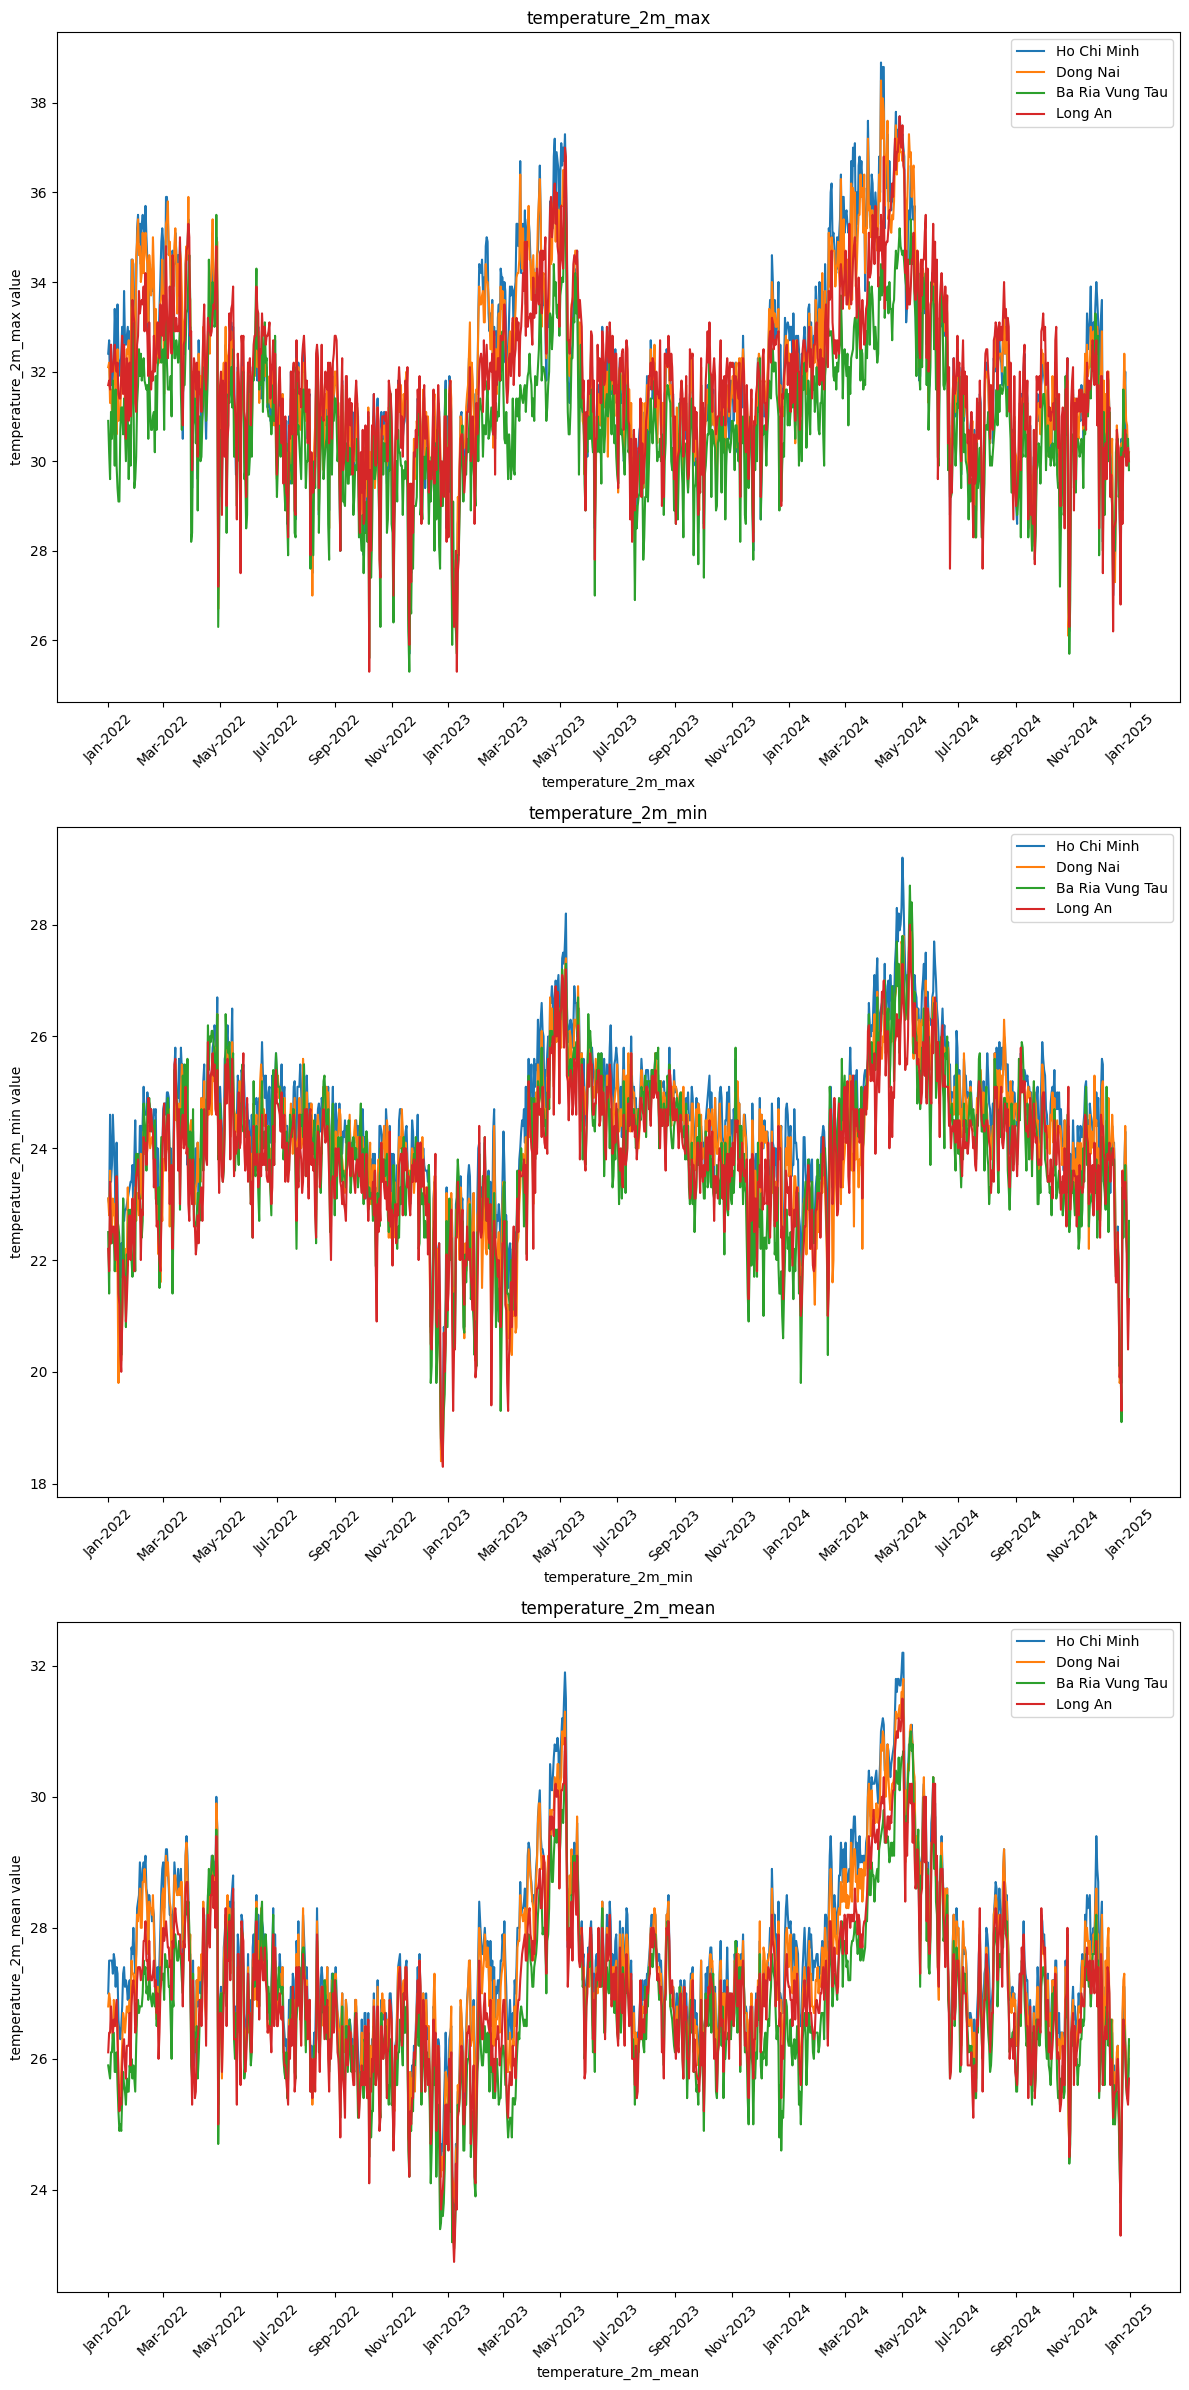

In [13]:
plot_region_data("South", south_cities, ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"])

1. North city 

rain sum:
+ Lượng mưa dày đặc vào các tháng 5 - 10
+ Lượng mưa tăng đột biến vào năm 2024 do sự đổ bộ của cơn bão Yagi -> trường hợp đặc biệt có thể note

wind speed:
+ Trải dài đều ở mức 5-20 km/h
+ Có thể thấy ở Quảng Ninh gió to hơn các nơi khác do vùng ven biển     

relative humidity (độ ẩm):
+ Độ ẩm cao ở mức 70-90 ở các tháng mùa mưa
+ Vào các tháng mùa khô 9 - 5 có xu hướng thấp hơn so với mùa mưa

dew_point (điểm sương):
+ Thấp vào mùa khô và cao vào mùa mưa 

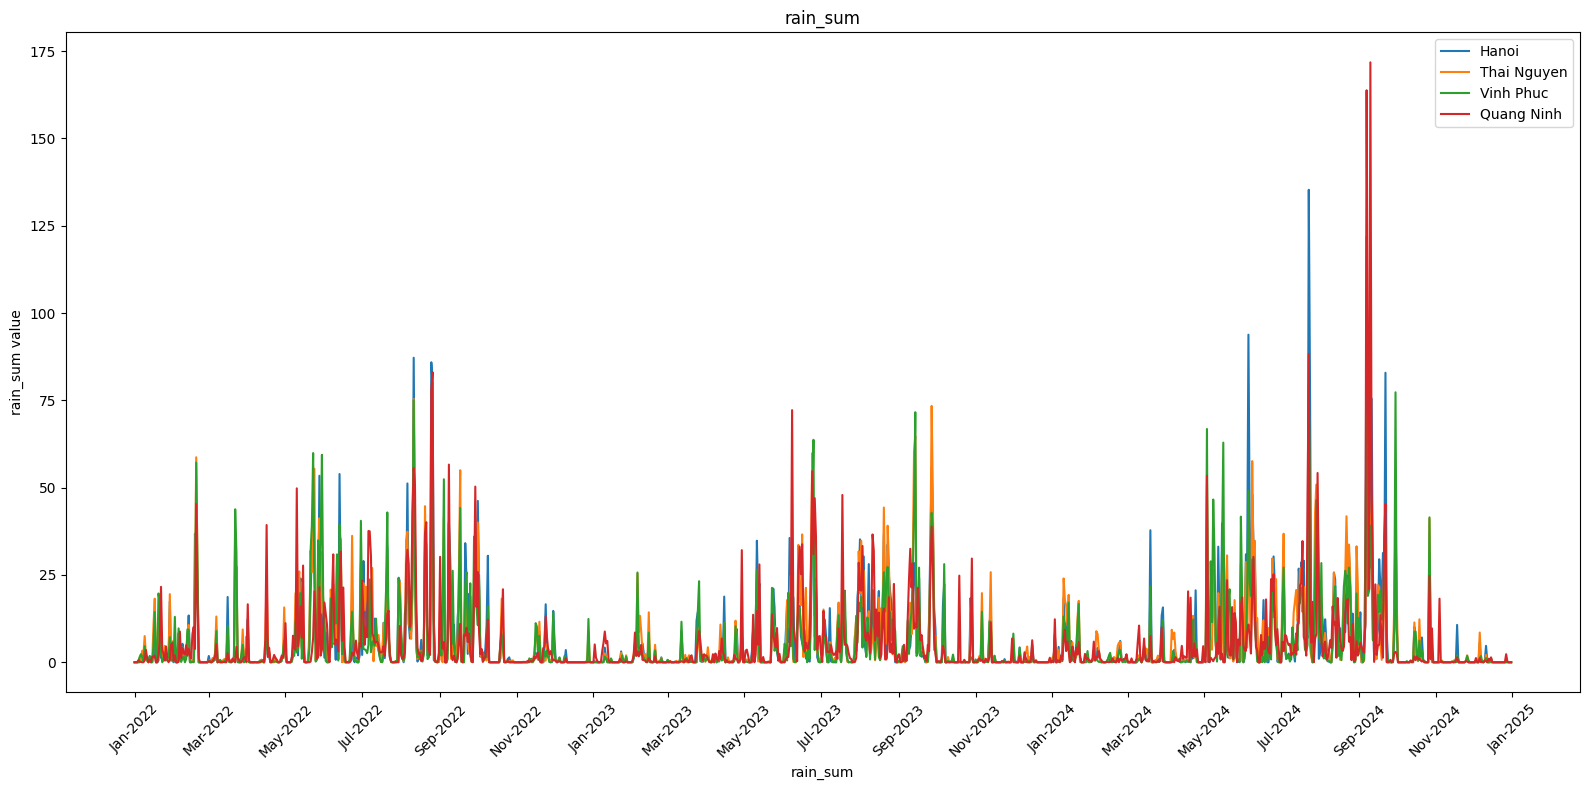

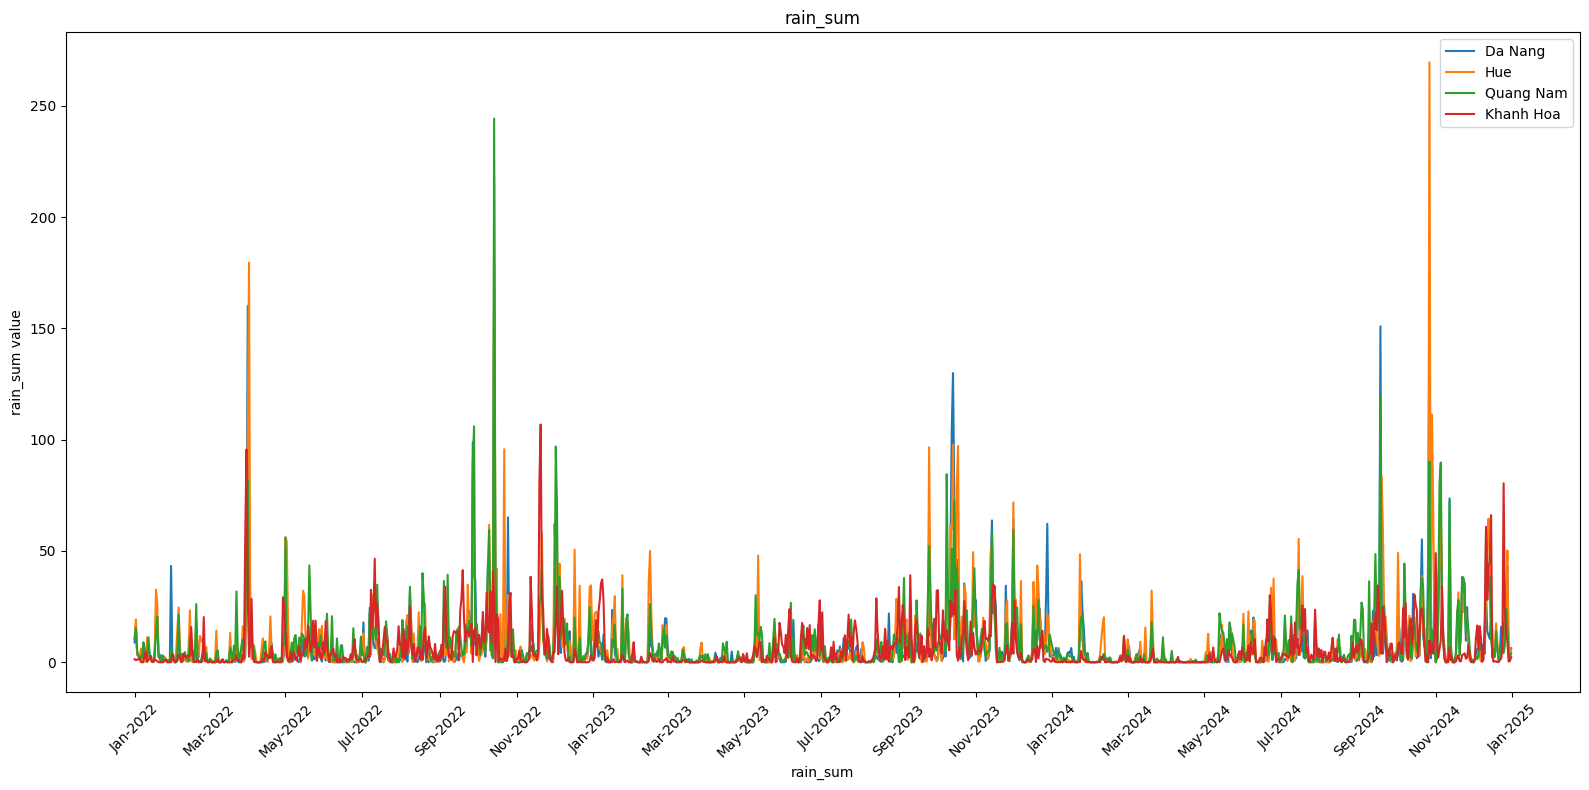

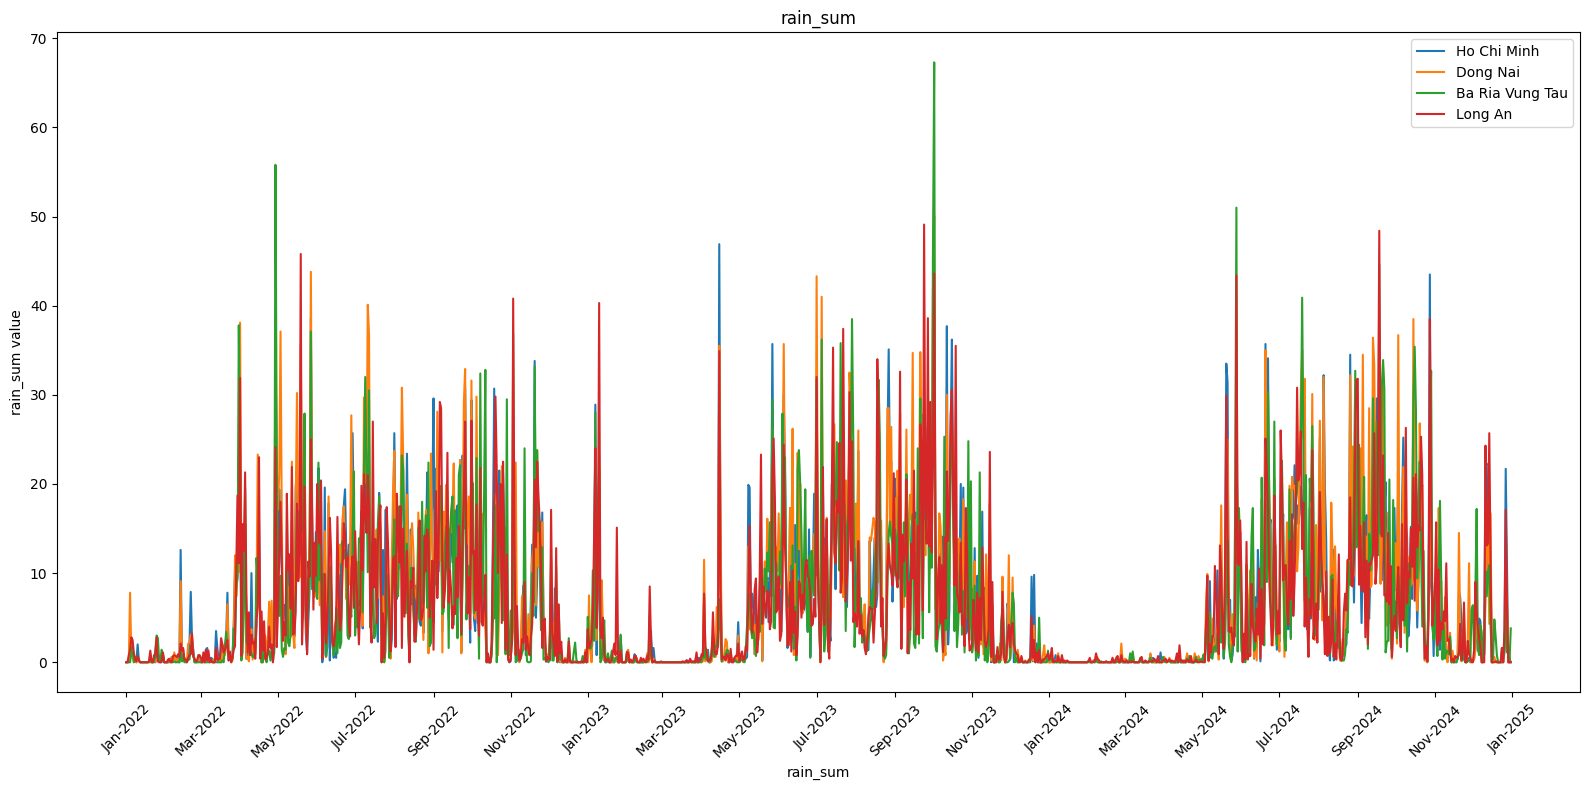

In [14]:
feature = ['rain_sum']
plot_region_data("North", north_cities, feature, fig=(16, 8))
plot_region_data("Central", central_cities, feature, fig=(16, 8))
plot_region_data("South", south_cities, feature, fig=(16, 8))

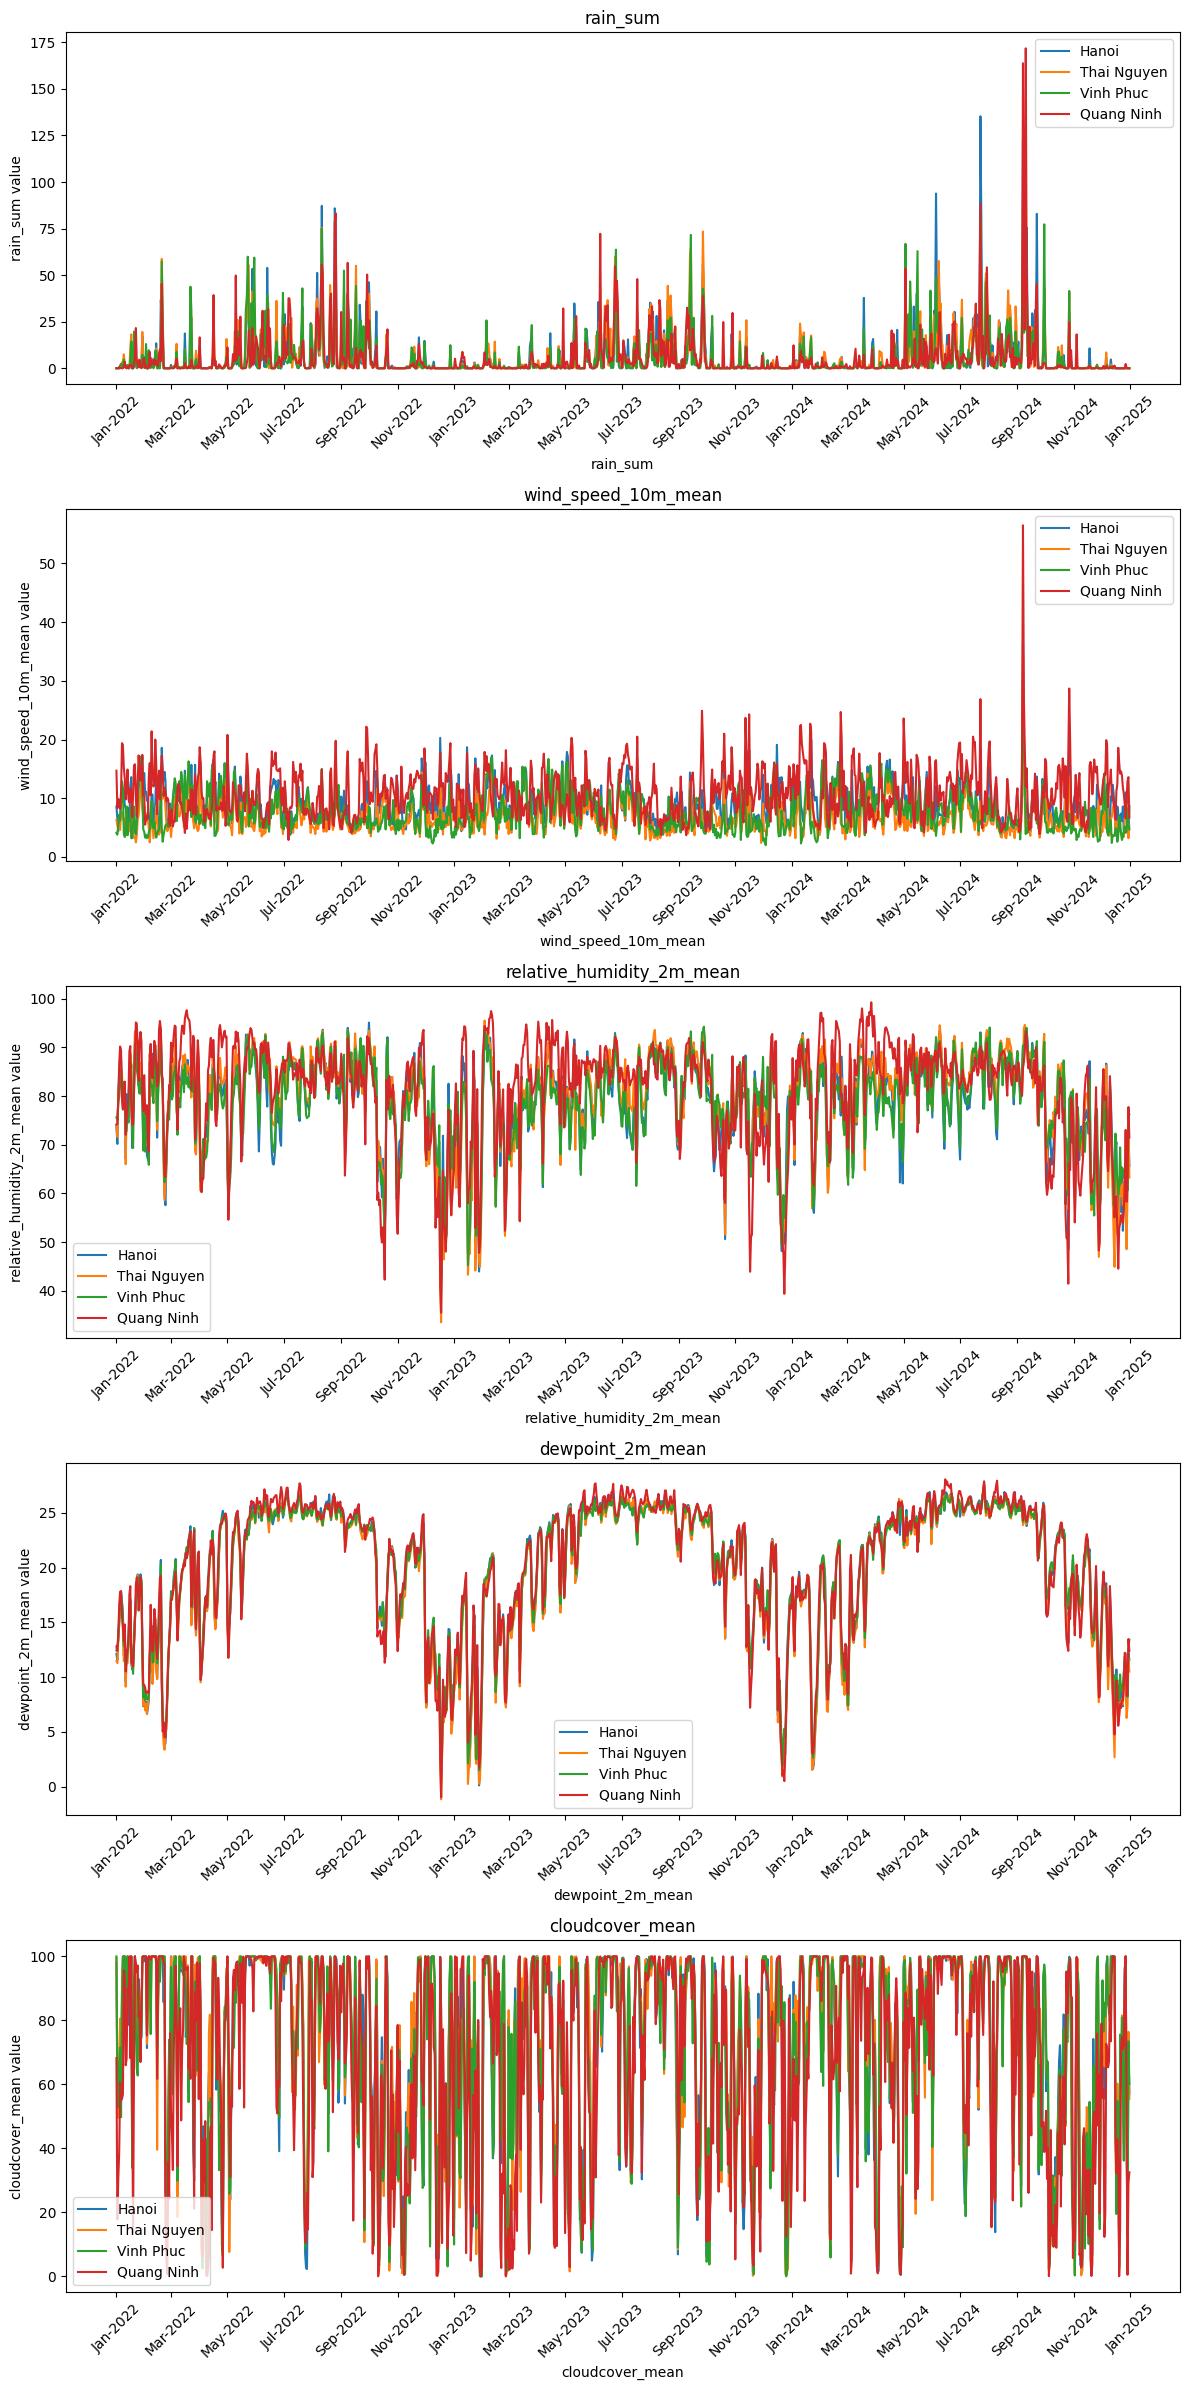

In [15]:
feature = ['rain_sum', 'wind_speed_10m_mean', 'relative_humidity_2m_mean', 'dewpoint_2m_mean', 'cloudcover_mean']
plot_region_data("North", north_cities, feature)

2. Central City 

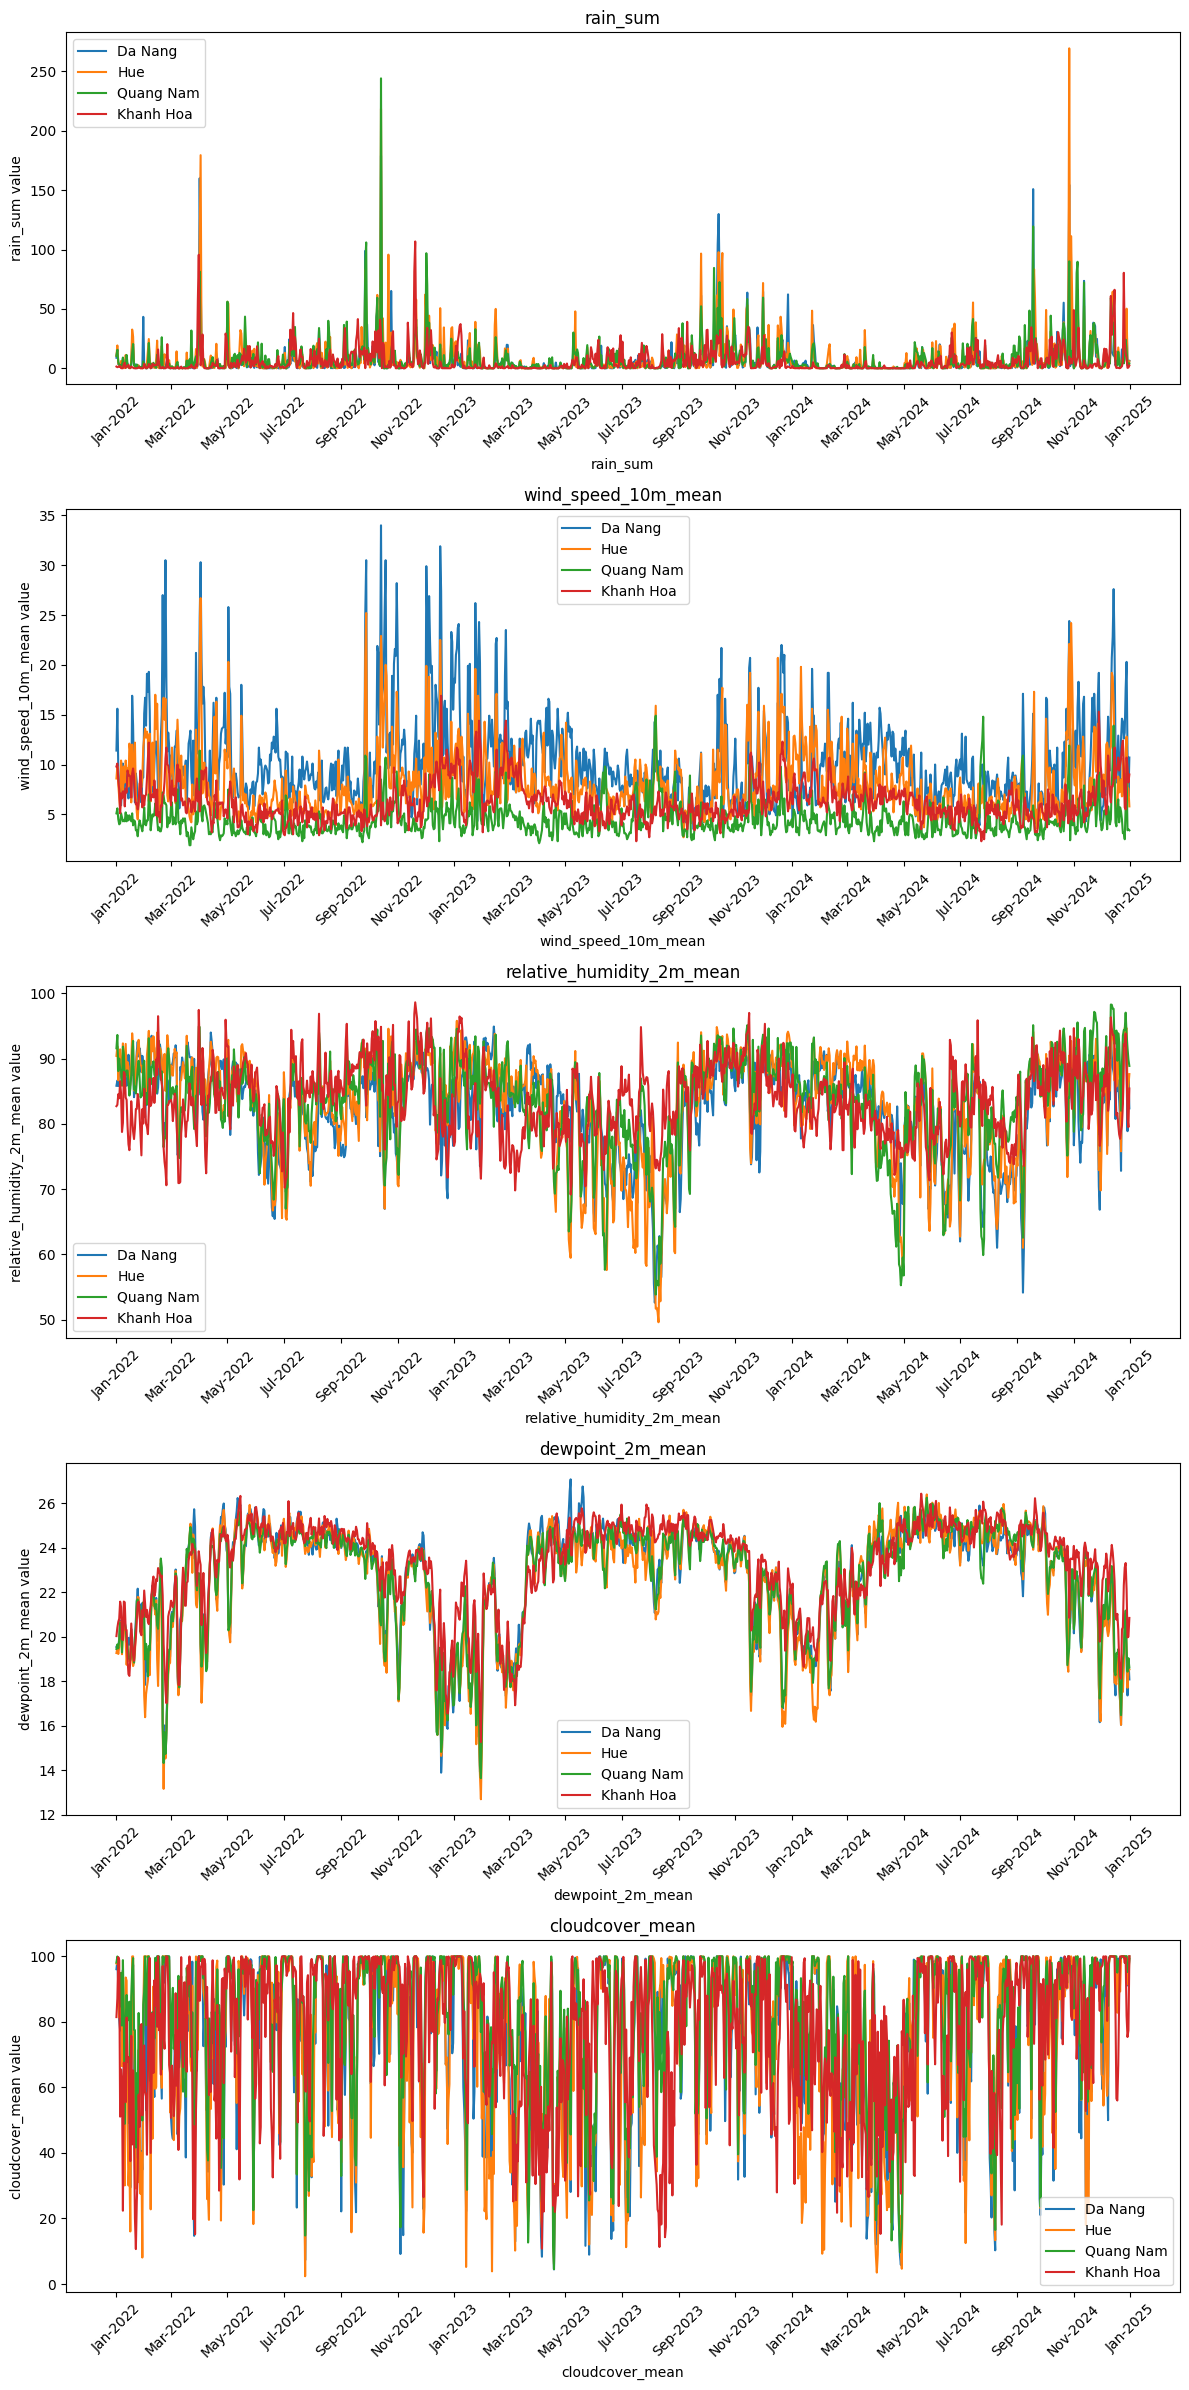

In [16]:
feature = ['rain_sum', 'wind_speed_10m_mean', 'relative_humidity_2m_mean', 'dewpoint_2m_mean', 'cloudcover_mean']
plot_region_data("Central", central_cities, feature)

3. South City

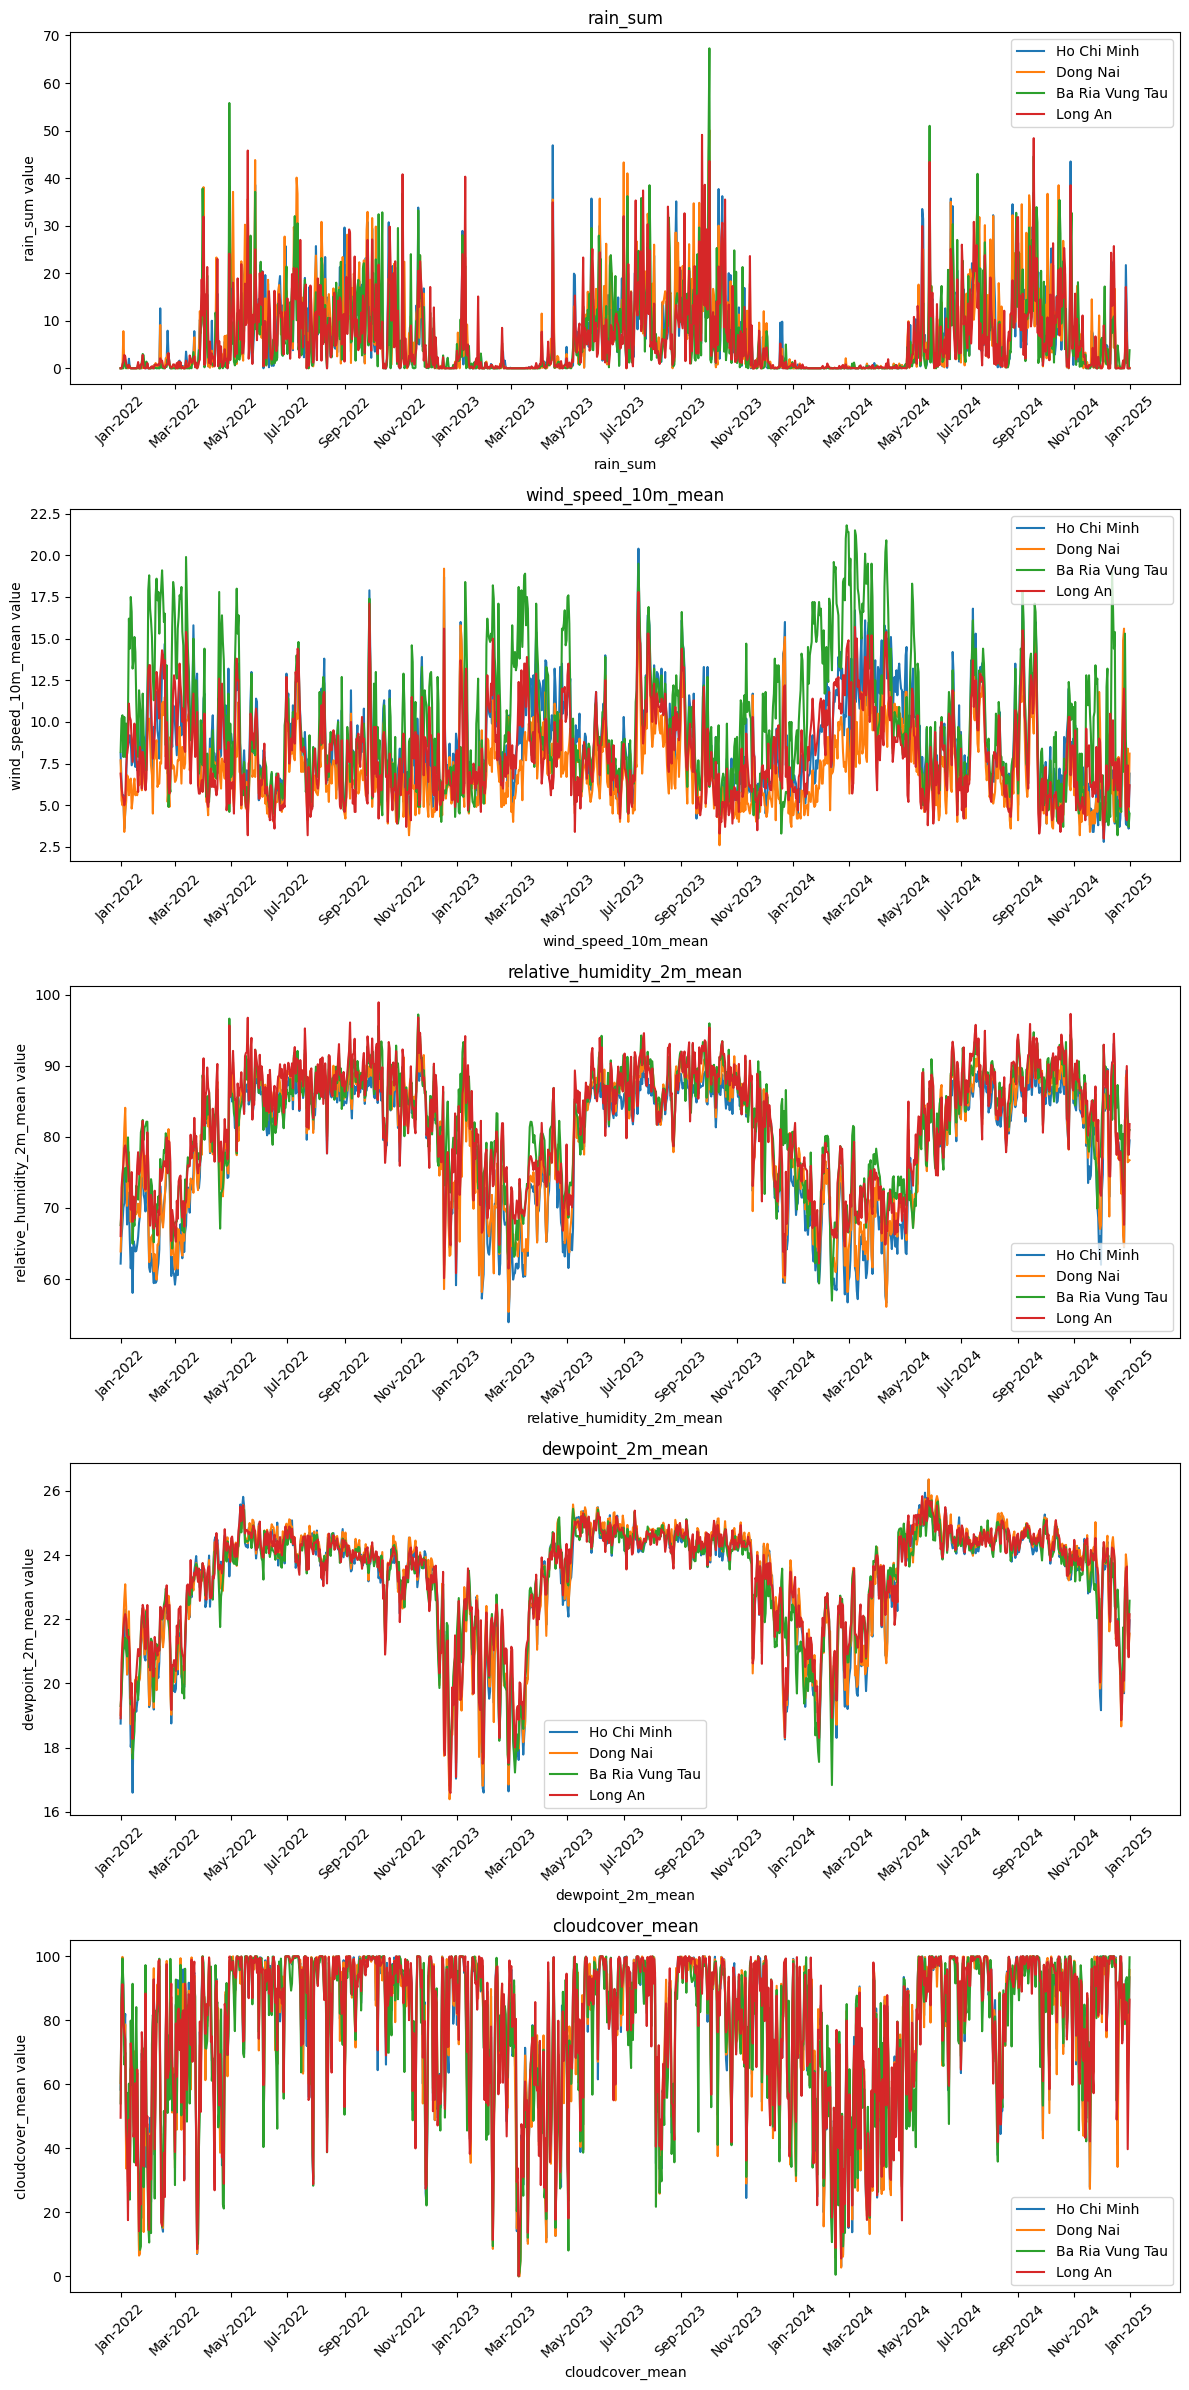

In [17]:
plot_region_data("South", south_cities, feature)

Dễ dàng thấy dewpoint và relative humidity đồng biến với các giá trị rain sum => có tác động hoặc có giá trị để predict value mưa trong khi độ che phủ của mây ko nói lên được gì 